<a href="https://colab.research.google.com/github/olympiasau/A01-data-wrangling/blob/main/2_0A02_eda_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is it always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

In [1]:
# Q2.1

import pandas as pd
!git clone https://github.com/olympiasau/A02-eda-and-visualization/
fg = pd.read_csv("./A02-eda-and-visualization/data/ForeignGifts_edu.csv")
fg.head()

fatal: destination path 'A02-eda-and-visualization' already exists and is not an empty directory.


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


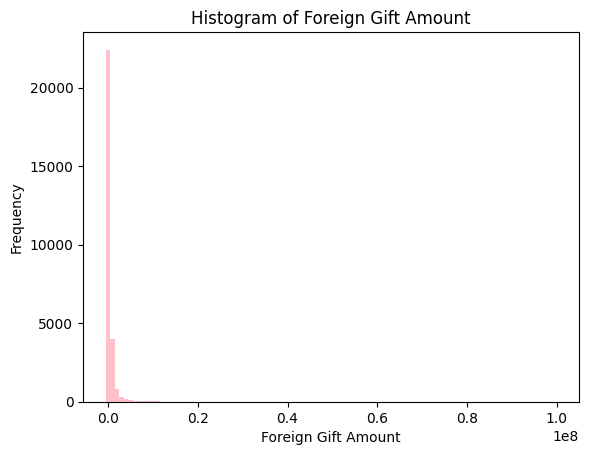

,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


In [2]:
# Q2.2: For Foreign Gift Amount, create a histogram and describe the variable.
# Describe your findings.
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.hist(fg['Foreign Gift Amount'],
         bins=100,
         color="pink")
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.title('Histogram of Foreign Gift Amount')
plt.show()

fg["Foreign Gift Amount"].describe()

# There are nearly 30k gifts averaging around 600k in currency. There is a
# relatively significant standard deviation due to an exterme outlier at
# 100 million in currency.



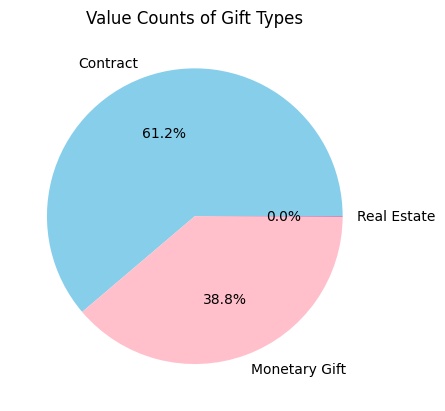

In [3]:
# Q2.3: For Gift Type, create a histogram or value counts table.
# What proportion of the gifts are contracts, real estate, and monetary gifts?
counts = fg['Gift Type'].value_counts()
counts.plot(kind='pie', autopct='%1.1f%%',
            colors= ['skyblue','pink','purple'])
plt.title("Value Counts of Gift Types")
plt.ylabel('')
plt.show()

# almost two thirds of the gifts are contracts, the majority remaining are monetary
# gifts, and there are very few (rounded to 0.0%) real estate gifts.

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Foreign Gift Amount', ylabel='Density'>

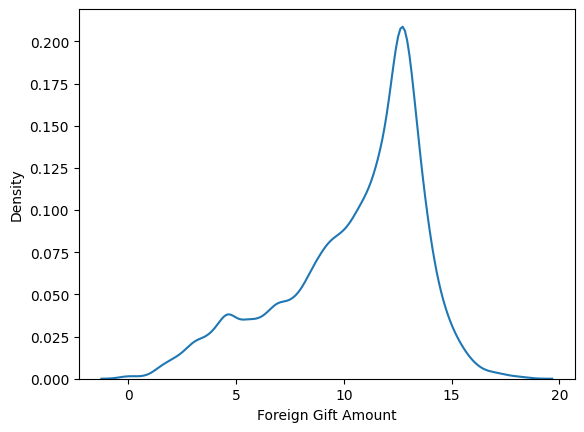

In [4]:
# Q2.4 Create a kernel density plot of the log of Foreign Gift Amount,
# and then a kernel density plot of the log of Foreign Gift Amount conditional
# on gift type. Do you notice any patterns?
fg['Foreign Gift Amount'] = np.log(fg['Foreign Gift Amount'])
sns.kdeplot(data=fg, x='Foreign Gift Amount')

# It seems like the greatest number of foreign gifts is around 13 units when
# looking at all gifts. However, when breaking it down to the three different
# gift types,

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Foreign Gift Amount', ylabel='Density'>

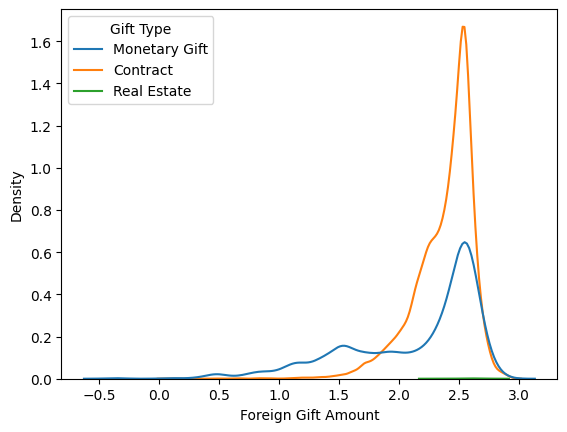

In [5]:
fg['Foreign Gift Amount'] = np.log(fg['Foreign Gift Amount'])
sns.kdeplot(data=fg, x='Foreign Gift Amount', hue='Gift Type')

In [6]:
# Q2.5 What are the top 15 countries in terms of the number of gifts?
# What are the top 15 countries in terms of the amount given?

giftor_country = fg.groupby('Country of Giftor').size().sort_values(ascending=False)
top15giftors = giftor_country.head(15)
top15giftors

,0
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [7]:
amount_country = fg.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)
top15_amount = amount_country.head(15)
top15_amount

,Foreign Gift Amount
Country of Giftor,
SAUDI ARABIA,3870.730435
GERMANY,3114.608471
QATAR,1755.393963
THE NETHERLANDS,1201.615778
KOREA,1094.408202
UNITED ARAB EMIRATES,908.315825
SINGAPORE,866.361958
TAIWAN,846.467275
ITALY,757.524907


In [8]:
# Q2.6 Which giftors provide the most money, in total?
giftor_money = fg.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
top15_giftors = giftor_money.head(15)
top15_giftors


,Foreign Gift Amount
Giftor Name,
Saudi Arabian Cultural Mission,1139.078593
Qatar Foundation,677.786905
Anonymous,675.050666
Human Frontier Science Program,611.469116
Novartis Pharmaceuticals Corp,527.343649
Royal Embassy of Saudi Arabia,475.226753
Acerta Pharma B.V.,461.225427
Contracting Party,357.497321
Qatar National Research Fund,313.961887


---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Olympia Sauerwein

**Date:** 10/9/26

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 39c5beb60f0798ccc141572119a835e79208e2fa
- **AI tool and model used:** Claude Sonnet 5

### *Prompts used

1. Review this and tell me what's wrong and how to fix it in the most basic way possible.

### *AI-proposed changes


1. Cell 6 overwrites the original `Foreign Gift Amount` column with its own log, destroying the real dollar values and producing NaN warnings (some amounts are negative, and log of a negative number is undefined). Fix: store the log in a new column instead of overwriting.
2. Cell 7 takes the log a second time of data that was already logged in cell 6, causing a "divide by zero" warning. Fix: reuse the same log column and just add `hue='Gift Type'`.
3. Because `Foreign Gift Amount` was overwritten with log values, the later sums by country (Q2.5) and giftor (Q2.6) summed logs instead of real dollars, giving meaningless totals. Fix: resolved automatically once cells 6-7 stop overwriting the original column.
4. Cell 3's `!git clone` prints a "fatal: destination path already exists" error every time the notebook is re-run. Fix: check whether the folder already exists before cloning.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | **Accept** | Overwriting the original column destroyed the real dollar values, so the log needed to go in a new column to keep both versions usable. |
| 2 | **Accept** | Reusing the same log column instead of re-logging avoids taking the log of already-logged (and sometimes zero) values, which caused the divide-by-zero warning. |
| 3 | **Accept** | This followed automatically from fixing #1 — once the original column is preserved, the country and giftor totals sum real dollars again instead of logs. |
| 4 | **Accept** | Checking whether the folder already exists before cloning avoids a harmless but confusing error message on re-runs. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [9]:
# Q2.1

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# FIX: only clone if the folder isn't already there, so re-running this cell
# doesn't print a "fatal: destination path already exists" error.
if not os.path.exists("A02-eda-and-visualization"):
    !git clone https://github.com/olympiasau/A02-eda-and-visualization/

fg = pd.read_csv("./A02-eda-and-visualization/data/ForeignGifts_edu.csv")
fg.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


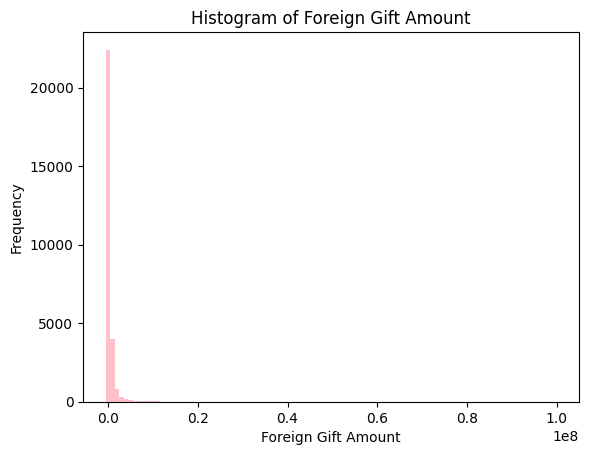

,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


In [10]:
# Q2.2: For Foreign Gift Amount, create a histogram and describe the variable.
# Describe your findings.
plt.hist(fg['Foreign Gift Amount'],
         bins=100,
         color="pink")
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.title('Histogram of Foreign Gift Amount')
plt.show()

fg["Foreign Gift Amount"].describe()

# There are nearly 30k gifts averaging around 600k in currency. There is a
# relatively significant standard deviation due to an extreme outlier at
# 100 million in currency.

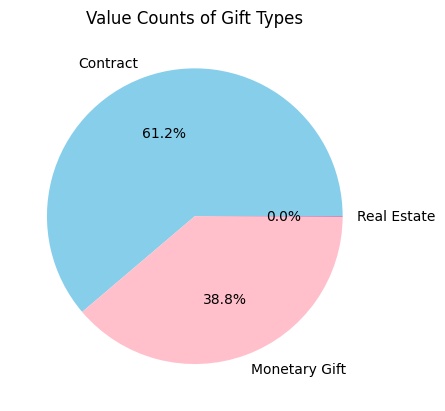

In [11]:
# Q2.3: For Gift Type, create a histogram or value counts table.
# What proportion of the gifts are contracts, real estate, and monetary gifts?
counts = fg['Gift Type'].value_counts()
counts.plot(kind='pie', autopct='%1.1f%%',
            colors=['skyblue', 'pink', 'purple'])
plt.title("Value Counts of Gift Types")
plt.ylabel('')
plt.show()

# almost two thirds of the gifts are contracts, the majority remaining are monetary
# gifts, and there are very few (rounded to 0.0%) real estate gifts.

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


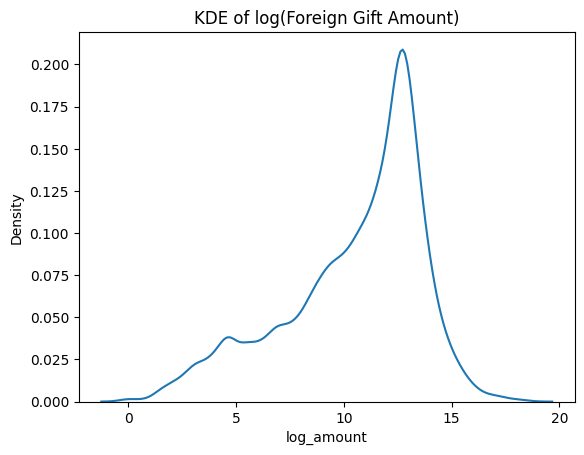

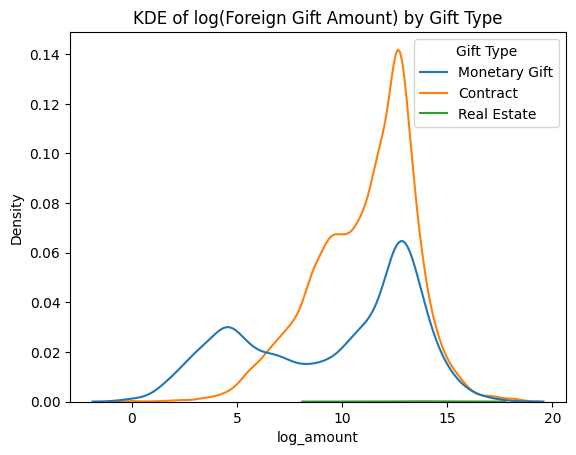

In [12]:
# Q2.4: Create a kernel density plot of the log of Foreign Gift Amount,
# and then a kernel density plot of the log of Foreign Gift Amount conditional
# on gift type. Do you notice any patterns?

# FIX: put the log values in a NEW column instead of overwriting
# 'Foreign Gift Amount', and only compute it once (not again in the next plot).
fg['log_amount'] = np.log(fg['Foreign Gift Amount'])

sns.kdeplot(data=fg, x='log_amount')
plt.title('KDE of log(Foreign Gift Amount)')
plt.show()

sns.kdeplot(data=fg, x='log_amount', hue='Gift Type')
plt.title('KDE of log(Foreign Gift Amount) by Gift Type')
plt.show()

# It seems like the greatest number of foreign gifts is around 13 log-units when
# looking at all gifts. Breaking it down by gift type shows each type has a
# somewhat different typical gift size.

In [13]:
# Q2.5: What are the top 15 countries in terms of the number of gifts?
# What are the top 15 countries in terms of the amount given?
giftor_country = fg.groupby('Country of Giftor').size().sort_values(ascending=False)
top15_count = giftor_country.head(15)
top15_count

,0
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [14]:
# FIX: this now sums the real 'Foreign Gift Amount' column (dollars),
# not the log-transformed values, because that column was never overwritten.
amount_country = fg.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)
top15_amount = amount_country.head(15)
top15_amount

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


In [15]:
# Q2.6 Which giftors provide the most money, in total?
giftor_money = fg.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
top15_giftors = giftor_money.head(15)
top15_giftors

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


### *Reflection on AI assistance
In your own words without generative AI.

Overall the second question did not give me significant challenges, so I was able to complete most of it correctly without revisions needed by Claude; however, it allowed me to sharpen and stabilize my coding to make it more robust. The first question was extremely difficult and not really something I have learned before, but using tutoring resources I was able to figure out what the questions were asking and solve by myself.